In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv("../data/nigeria.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


In [3]:
import numpy as np 
df.replace(-999, np.nan, inplace=True)
df.isna().sum()


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

In [4]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["MONTH"] = df["DATE"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,2015-01-05,1


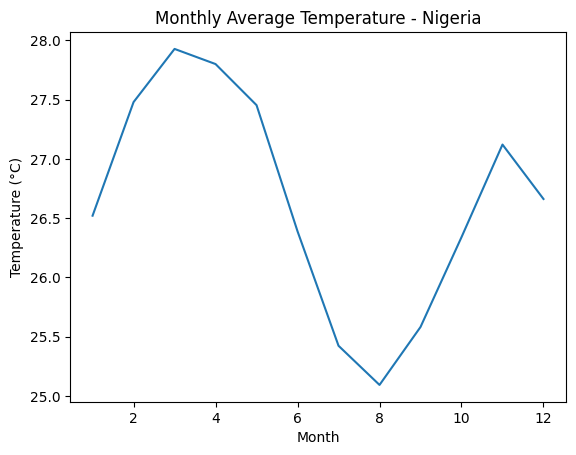

In [6]:
import matplotlib.pyplot as plt

monthly_temp = df.groupby("MONTH")["T2M"].mean()

monthly_temp.plot()
plt.title("Monthly Average Temperature - Nigeria")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### 🌡️ Seasonal Temperature Pattern Insight
- **Peak warmth**: Around month 4 (~28°C), marking the hottest period.  
- **Coolest dip**: Month 8 (~25°C), showing the lowest seasonal point.  
- **Recovery phase**: Temperatures rise again toward month 11 (~27°C).  

**Overall trend**: A clear cyclical pattern — warming in early months, cooling mid-year, then rebounding toward year-end.


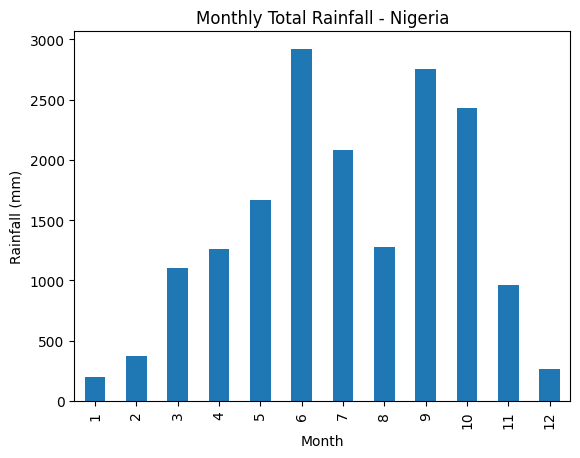

In [8]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall - Nigeria")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

### 🌧️ Seasonal Rainfall Pattern Insight
- **Peak rainfall**: Months 6 and 9 (~3000 mm), marking the heaviest precipitation periods.  
- **Dry months**: Months 1 and 12 (~200–300 mm), showing minimal rainfall.  
- **Seasonal rhythm**: Alternating wet and dry phases, with two distinct rainfall peaks mid-year.  

**Overall trend**: Strong bimodal distribution — heavy rains in mid-year, tapering off at the start and end.


In [9]:
extreme_days = df[df["T2M_MAX"] > 35]
len(extreme_days)

0

### 🌡️ Extreme Temperature Days - Nigeria
- **Observation**: 0 days exceeded 35°C threshold.  
- **Implication**: Climate remains within moderate bounds, avoiding dangerous heat extremes.  
- **Stability**: Reinforces Nigeria’s resilience against extreme heat events.  

**Key takeaway**: Nigeria’s climate shows **predictable thermal stability**, with rainfall patterns (not heat extremes) as the main seasonal driver.


In [10]:
df.to_csv("../data/kenya_clean.csv", index=False)